## Splash Test 💧💧💧💧

<div class="alert alert-block alert-success">

## Part 4: Analyzing Cubed-Sphere $\texttt{PADDLE}$ Outputs

After running the simulation to completion in **Part 3**, the output directory (`splash_results`) should be populated by the following files: 

1. No restart files, since we specified we didn't want any in our `.yaml` file
2. *shallow_splash.out0.XXXXX.nc* (XXXXXX ranging from 00000-00086)

These were generated since we had our simulation run for 10 days (`integration:tlim:900`), and had the following $\texttt{output}$ setting defined in our `.yaml` file: 

`type: netcdf: variables: [prim] : dt: 1e4.`

Meaning we had .nc files (storing the primitive variables for shallow water: geopotential, velocities 1-3) defined in **Part 3**).

Now, we will combine our .nc files into a single output file and explore how to visualize our simulation results.
</div>

<div class="alert alert-info">

## Combine .nc files 

1. cd into the output directory `splash_results`

2. Combine the files using (combining the out0 files into a single -main file)

```
pd-combine 0 -o main
```

This can be run in terminal, or can be done in this Jupyter notebook as a shell command.

**NOTE: The following will delete your .nc files. If you wish to keep them, for whatever reason, copy them into a different directory.**

In [1]:
# Combine our out1 files into straka_made_in_notebook-main.nc (or, straka-main.nc if you used the default .yaml file)

!(cd splash_results/ && pd-combine 0 -o main)

##########################
## Combine output files ##
##########################
Working on case shallow_splash...
Combining FITS output ...
Concatenating output field out0 ...
Combining output fields:  0 to main
Done.



<div class="alert alert-info">

## View straka-main.nc with $\texttt{ncview}$

We can use another terminal command that calls `ncview` to view our combined .nc file.

$\texttt{ncview}$ is a great tool for a quick look at our simulation's results. 

For cubed-sphere, $\texttt{ncview}$ will display the 6 cube faces, which can be a bit counter-intuitive. We will label their relations in the figure below. 

When utilizing $\texttt{ncview}$, click `rho` (which, in shallow splash is geopotential NOT density) and press play to see how the splash propagates from North to South pole. 

**NOTE: If you don't have ncview installed, view the INSTALLATION instructions of $\texttt{PADDLE}$**

<img src="../../../images/CubedSphere1.png">

Here, we have manually unfolded a Cubed-Sphere result with visible cloud features to better show how to think about interpreting the Cubed Sphere panels. 

While you can post-process cubed-sphere results onto a lat-lon grid, or spherical projection, while running a simulation you often want to do quick checks with ncview to make sure the simulation is running correctly, so it is worthwhile to become comfortable with the projection. 

<img src="../../../images/CubedSphere2.png">

We unfold the above by placing the equatorial regions together, and rotating the North and South Poles to match each equatorial face. 

<img src="../../../images/CubedSphere3.png">

In [3]:
!(cd splash_results/ && ncview shallow_splash-main.nc)

Ncview 2.1.8 David W. Pierce  8 March 2017
http://meteora.ucsd.edu:80/~pierce/ncview_home_page.html
Copyright (C) 1993 through 2015, David W. Pierce
Ncview comes with ABSOLUTELY NO WARRANTY; for details type `ncview -w'.
This is free software licensed under the Gnu General Public License version 3; type `ncview -c' for redistribution details.

Note: no Ncview app-defaults file found, using internal defaults
calculating min and maxes for rho...
X connection to /private/tmp/com.apple.launchd.YXSANVCZh4/org.xquartz:0 broken (explicit kill or server shutdown).


<div class="alert alert-info">

## Load in the nc file

We can also load the .nc file directly in a notebook. While this a bit more tedious than using $\texttt{ncview}$, it is useful when wanting to project your cubed-sphere results onto geometries that are easier to visually digest. 

</div>

In [ ]:
import netCDF4
import numpy as np

# Open the file
splash_output = netCDF4.Dataset('./splash_results/shallow_splash-main.nc', 'r')

# Print the dimensions
# x1 is the coordinate of cell centers while x1f is cell boundaries (length is 1 longer)
print(splash_output.dimensions.keys())

# Print the stored variables
print(splash_output.variables.keys())

# Lets plot the geopotential
# For shallow water, rho = geopotential
data_geopotential = splash_output.variables['rho'][:]

# 87 frames
# 1 cell by 96 cells by 144 cells
print(np.shape(data_geopotential))


dict_keys(['time', 'x1', 'x2', 'x2f', 'x3', 'x3f'])
dict_keys(['time', 'x1', 'x2', 'x2f', 'x3', 'x3f', 'rho', 'vel1', 'vel2', 'vel3', 'lon', 'lat'])
(87, 1, 96, 144)


Here we can look at how outputs are stored for the cubed sphere format. While the array shape of the data might seem counter-intuitive, it is actually saved in the same shape as what we saw in ncview. 

The 1 cell is the vertical direction (here 1 because its a shallow water model), while 96 represents the two rows of panels (each 48 cells wide) and 144 represents three columns of panels (each 48 cells wide). 

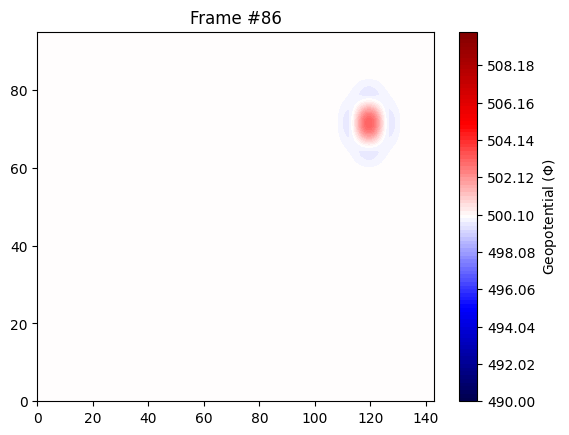

In [28]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Loop over the time saved frames 
for t in range(np.shape(data_geopotential)[0]):

    # Ensures that the last plot will be cleared 
    clear_output(wait = True)

    # Make a countour plot
    plt.contourf(data_geopotential[t,0,:,:], cmap = 'seismic', levels = np.linspace(490,510,100))
    plt.colorbar(label = 'Geopotential ($\Phi$)')
    title = 'Frame #' + str(t)
    plt.title(title)
    plt.show()

    # Delay, so that it doesn't go too fast 
    time.sleep(0.1)

Next, we will try and project this onto a lat-lon grid, and a spherical projection, for better visualization. 

Physical Units

<div class="alert alert-block alert-success">

Congratulations on reaching the end of your first $\texttt{PADDLE}$ tutorial to use the cubed-sphere!

In **GCM Benchmarks**, we will utilize this geometry to simulate more realistic planetary atmospheres. 